In [1]:
import pandas as pd

from nsfg.paths import raw, interim
import numpy as np
import matplotlib.pyplot as plt

from nsfg.utils import decorate, value_counts
from nsfg.utils import add_title, add_logo, add_subtext

In [2]:
%load_ext autoreload
%autoreload 2

## Configure matplotlib

To install PT Sans:

```
sudo apt install fonts-paratype
fc-cache -fv
fc-list | grep "PT Sans"
rm ~/.cache/matplotlib/fontlist-v390.json 
```

Restart Python/Jupyter and run the following:

In [3]:
import matplotlib.font_manager as fm

# Get list of available fonts
available_fonts = set(f.name for f in fm.fontManager.ttflist)

# Check for specific fonts
print("PT Sans is available:", "PT Sans" in available_fonts)
print("Skolar Sans is available:", "Skolar Sans" in available_fonts)

PT Sans is available: True
Skolar Sans is available: False


In [4]:
# Make the figures smaller to save some screen real estate.
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = [6.75, 3.5]

aibm_light_gray = "#F3F4F3"
aibm_medium_gray = "#767676"
aibm_green = "#0B8569"
light_green = "#AAC9B8"
aibm_orange = "#C55300"
light_orange = "#F4A26B"
aibm_purple = "#9657A5"
light_purple = "#CFBCD0"
aibm_blue = "#4575D6"
light_blue = "#C9D3E8"

# additional colors from coolers.co
dark_gray = "#404040"
dark_purple = "#28112B"
dark_green = "#002500"
amber = "#F5BB00"
oxford_blue = "#000022"
bittersweet = "#FF6666"
crimson = "#D62839"

rainbow = [crimson, aibm_orange, amber, aibm_green, aibm_blue, aibm_purple]
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=rainbow)

plt.rcParams["axes.edgecolor"] = aibm_medium_gray  # Spines (axis border)
plt.rcParams["xtick.color"] = aibm_medium_gray  # X-axis ticks
plt.rcParams["ytick.color"] = aibm_medium_gray  # Y-axis ticks
plt.rcParams["axes.labelcolor"] = aibm_medium_gray  # Axis labels

# remove all spines
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.left"] = False
plt.rcParams["axes.spines.bottom"] = False

# light gray horizontal grid lines
plt.rcParams["grid.color"] = aibm_light_gray
plt.rcParams["grid.linestyle"] = "-"  # Solid lines
plt.rcParams["grid.linewidth"] = 1  # Thin lines
plt.rcParams["axes.grid"] = True  # Enable grid
plt.rcParams["axes.grid.axis"] = "y"  # Apply only to horizontal lines

# Remove tick marks
plt.rcParams["xtick.major.size"] = 0
plt.rcParams["xtick.minor.size"] = 0
plt.rcParams["ytick.major.size"] = 0
plt.rcParams["ytick.minor.size"] = 0

# use rcparams to remove the tick marks -- generate code only

plt.rcParams["font.family"] = "PT Sans"  # Use PT Sans as the default font

## CPS Fertility Data

In [5]:
# Read the Census data

from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download(
    "https://www2.census.gov/programs-surveys/demo/tables/fertility/time-series/his-cps/h2.xlsx"
)

In [6]:
rename_dict = {
    "Unnamed: 0": "Year",
    "Unnamed: 1": "Total",
    "Unnamed: 12": "Rate per 1000",
}

df = pd.read_excel(raw("h2.xlsx"), skiprows=6)
del df["Unnamed: 7"]
df.rename(columns=rename_dict, inplace=True)
df.head()

,Year,Total,Total,None,One,Two,Three,Four,Five and six,Unnamed: 10,Seven or more,Rate per 1000
0,All Marital Classes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,.Women 45-50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,.2022,12060,100,16.5,19.3,35.7,17.3,6.8,4.4,/1,N,1916
3,.2020 /2,12170,100,15.1,19.6,35.1,18,7.6,3.7,NaN,0.9,2008
4,.2018,12520,100,15.4,19.8,35.4,17.3,7.4,3.6,NaN,1.2,1999


In [7]:
# Select women ages 40-44

rows = df.iloc[9:39].drop(36)

In [8]:
# Convert the index to integers

index = rows["Year"].astype(float) * 10000
rows.index = index.round().astype(int)

In [9]:
# (Almost) Completed Cohort Fertility Rate
# Usually age 50, but with this dataset, 40-45 is what we have

cfr = rows["Rate per 1000"] / 1000

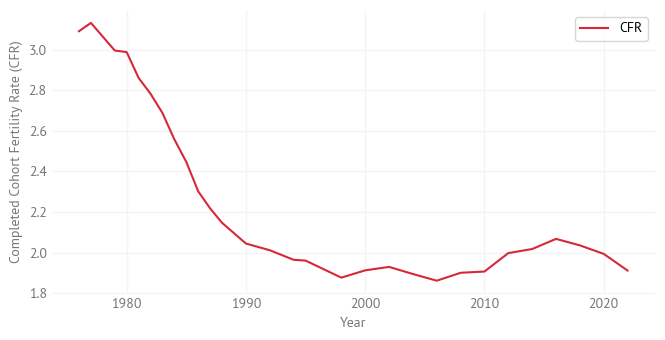

In [10]:
cfr.plot(label="CFR")
decorate(ylabel="Completed Cohort Fertility Rate (CFR)")

## Female Data

In [11]:
df = pd.read_parquet(interim("FemMarriageData.parquet"))
df.shape

(75769, 53)

In [12]:
trimmed = df["parity"] > 12
df.loc[trimmed, "parity"] = np.nan

In [13]:
from nsfg.utils import round_into_bins

df["age_group"] = round_into_bins(df["ager"], 3, low=14) + 1

In [14]:
pd.crosstab(df["age_group"], df["cycle"])

cycle,3,4,5,6,7,8,9,10,11,12
age_group,,,,,,,,,,
15.0,569,440,547,433,842,375,362,362,363,256
18.0,1319,780,862,708,1427,660,642,562,607,474
21.0,904,780,865,808,1255,558,530,394,439,364
24.0,864,841,963,816,1293,599,661,542,574,389
27.0,923,945,1011,775,1445,635,611,554,605,473
30.0,882,1022,1223,827,1395,657,621,547,626,587
33.0,766,1018,1340,790,1120,555,611,520,628,624
36.0,601,914,1292,799,1090,505,562,475,537,559
39.0,528,783,1243,724,1064,450,448,408,458,547


In [15]:
df["birth_group"] = round_into_bins(df["year"], 3, low=0) + 1

In [16]:
# Derived indicator columns for the female frame. These were defined for df2
# further down but never for df, which broke every cell below that used them.
# Definitions follow intent.ipynb and this notebook's own prose.
df["intent_yes"] = np.where(df["intent"].isna(), np.nan, df["intent"] == 1)
df["want_yes"] = np.where(df["rwant"].isna(), np.nan, df["rwant"] == 1)

# strl_yes is tubal ligation, hysterectomy or "other operation";
# strl_tubs is tubal ligation alone
df["strl_yes"] = (df["tubs"] == 1) | (df["hyst"] == 1) | (df["strloper"] == 4)
df["strl_tubs"] = df["tubs"] == 1

# child_yes is based on parity, which is a recode
df["child_yes"] = np.where(df["parity"].isna(), np.nan, df["parity"] > 0)

In [17]:
pd.crosstab(df["birth_group"], df["cycle"])

cycle,3,4,5,6,7,8,9,10,11,12
birth_group,,,,,,,,,,
37,179,0,0,0,0,0,0,0,0,0
40,460,0,0,0,0,0,0,0,0,0
43,519,363,0,0,0,0,0,0,0,0
46,626,754,0,0,0,0,0,0,0,0
49,765,820,226,0,0,0,0,0,0,0
52,887,921,1160,0,0,0,0,0,0,0
55,916,1018,1236,0,0,0,0,0,0,0
58,865,997,1296,556,0,0,0,0,0,0
61,908,965,1310,712,97,0,0,0,0,0


### Resampling

In [18]:
from nsfg.utils import resample_by_cycle

sample = resample_by_cycle(df)

In [19]:
table = sample.groupby(["age_group", "birth_group"])["parity"].agg(["sum", "count"])

In [20]:
def make_table(df, var, drop_cols=[]):
    table = df.groupby(["age_group", "birth_group"])[var].mean().unstack()
    if drop_cols:
        table.drop(columns=drop_cols, errors="ignore", inplace=True)
    return table

In [21]:
def plot_table(table):
    """ """
    for col in table.columns:
        table[col].plot(label="", alpha=0.3)

In [22]:
table = make_table(sample, "parity")
cohorts = table.columns
ages = table.index

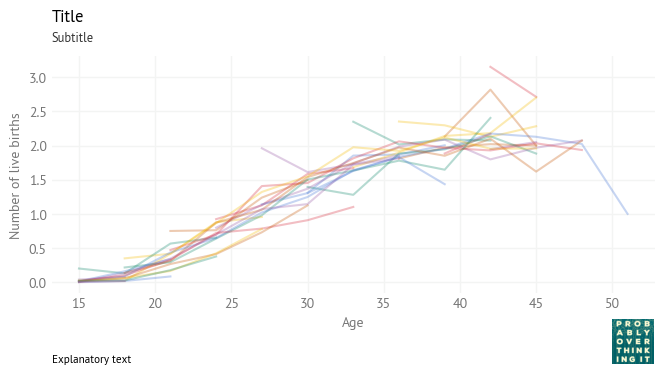

In [23]:
plot_table(table)
title = "Title"
subtitle = "Subtitle"
add_title(title, subtitle)

subtext = """
Explanatory text"""
add_subtext(subtext)

decorate(xlabel="Age", ylabel="Number of live births")
add_logo()
None

In [24]:
from nsfg.utils import percentile_rows


def plot_table_with_errors(tables, cohorts, ages):
    table = tables[0]
    rows, cols = table.shape
    # set_palette("nipy_spectral", len(cohorts), reverse=True)

    for cohort in cohorts:
        frame = pd.DataFrame(columns=ages)
        for i, table in enumerate(tables):
            frame.loc[i] = table[cohort]

        # using the 84% CI, so non-overlapping corresponds to
        # a difference that's significant at 5% level
        low, median, high = percentile_rows(frame, [8, 50, 92])
        plt.fill_between(ages, low, high, alpha=0.15)
        plt.plot(ages, median, label=cohort, alpha=0.6)

In [25]:
from nsfg.marriage import underride


def add_question_text(text, **options):
    underride(
        options, ha="left", va="bottom", color="0.2", fontname="PT Sans", fontsize=9
    )
    ax = plt.gca()
    ax.text(0.04, 0.05, text, transform=ax.transAxes, **options)

In [26]:
def summarize_age_groups(df, var, age_groups):
    columns = np.sort(df["birth_index"].unique())
    res = pd.DataFrame(dtype=float, columns=columns)

    for i in range(101):
        sample = resample_by_cycle(df).query("age_group in @age_groups")
        row = sample.groupby("birth_index")[var].mean() * 100
        res.loc[i] = row

    return res.mean(axis=0)

In [27]:
def summarize_age_group(tables, age_group):
    df = pd.DataFrame(dtype=float, columns=tables[0].columns)

    for i, table in enumerate(tables):
        df.loc[i] = table.loc[age_group]

    return df.mean()

In [28]:
def savefig(fig_number, extra_artist):
    filename = f"nsfg_fertility{fig_number:02d}"
    plt.savefig(
        filename, dpi=150, bbox_inches="tight", bbox_extra_artists=[extra_artist]
    )

### Intend to have another child

Looking to the future, do you intend to have a/another baby at some time?

In [29]:
tables = [make_table(resample_by_cycle(df), "intent_yes") * 100 for i in range(101)]

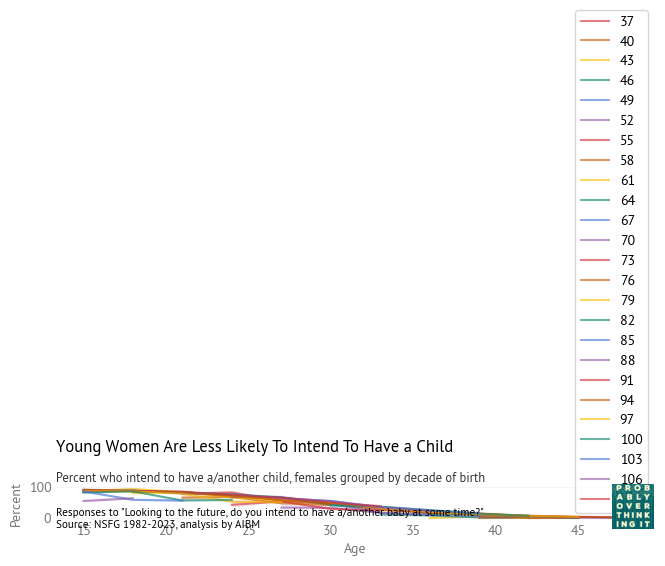

In [30]:
plot_table_with_errors(tables, cohorts, ages)
title = "Young Women Are Less Likely To Intend To Have a Child"
subtitle = (
    "Percent who intend to have a/another child, females grouped by decade of birth"
)
add_title(title, subtitle)

subtext = """
Responses to "Looking to the future, do you intend to have a/another baby at some time?"
Source: NSFG 1982-2023, analysis by AIBM"""
add_subtext(subtext)

decorate(xlabel="Age", ylabel="Percent")
inset = add_logo()
savefig(3, inset)

In [31]:
age_groups = [15, 18, 21, 24]
summarize_age_groups(df, "intent_yes", age_groups).dropna()

50     67.502387
60     82.388158
70     80.803698
80     81.954729
90     81.589780
100    68.574996
dtype: float64

### Percent who want to have another child

Looking to the future, do you, yourself, _want_ to have a/another baby at
some time?

In [32]:
tables = [make_table(resample_by_cycle(df), "want_yes") * 100 for i in range(101)]

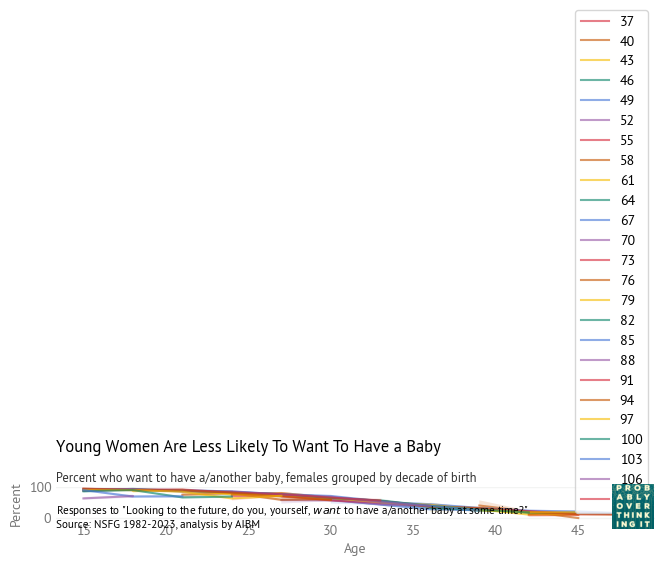

In [33]:
plot_table_with_errors(tables, cohorts, ages)
title = "Young Women Are Less Likely To Want To Have a Baby"
subtitle = "Percent who want to have a/another baby, females grouped by decade of birth"
add_title(title, subtitle)

subtext = """
Responses to "Looking to the future, do you, yourself, $want$ to have a/another baby at some time?"
Source: NSFG 1982-2023, analysis by AIBM"""
add_subtext(subtext)

decorate(xlabel="Age", ylabel="Percent")
inset = add_logo()
savefig(2, inset)

In [34]:
summarize_age_group(tables, 24)

birth_group
37           NaN
40           NaN
43           NaN
46           NaN
49           NaN
52           NaN
55     70.025646
58     78.903876
61     75.318139
64     83.702988
67           NaN
70           NaN
73           NaN
76     75.943336
79     78.904558
82     82.649242
85     84.463140
88     85.112562
91     81.563622
94     81.008038
97     62.712809
100    68.509450
103          NaN
106          NaN
109          NaN
dtype: float64

In [35]:
summarize_age_group(tables, 24)

birth_group
37           NaN
40           NaN
43           NaN
46           NaN
49           NaN
52           NaN
55     70.025646
58     78.903876
61     75.318139
64     83.702988
67           NaN
70           NaN
73           NaN
76     75.943336
79     78.904558
82     82.649242
85     84.463140
88     85.112562
91     81.563622
94     81.008038
97     62.712809
100    68.509450
103          NaN
106          NaN
109          NaN
dtype: float64

"Among women aged 15 to 24 in this birth cohort, 76% say they want to become mothers, markedly lower than the 87% for women born in the 1980s and 1990s"

In [36]:
age_groups = [15, 18, 21, 24]
summarize_age_groups(df, "want_yes", age_groups).dropna()

50     78.777979
60     88.254736
70     84.641817
80     87.055553
90     86.401005
100    74.669721
dtype: float64

### Number of live births

parity is a recoded variable, so there's no single question it corresponds to

In [37]:
tables = [make_table(resample_by_cycle(df), "parity") for i in range(101)]

In [38]:
summary = summarize_age_group(tables, 24)
summary.round(1)

birth_group
37     NaN
40     NaN
43     NaN
46     NaN
49     NaN
52     NaN
55     1.0
58     0.8
61     0.9
64     0.7
67     NaN
70     0.8
73     0.6
76     0.9
79     0.8
82     0.7
85     0.6
88     0.7
91     0.7
94     0.4
97     0.5
100    0.3
103    NaN
106    NaN
109    NaN
dtype: float64

In [39]:
summary = summarize_age_group(tables, 33)
summary.round(1)

birth_group
37     NaN
40     NaN
43     NaN
46     2.4
49     1.9
52     1.7
55     1.6
58     NaN
61     1.7
64     1.4
67     1.7
70     1.7
73     1.9
76     1.7
79     1.9
82     1.7
85     1.6
88     1.5
91     1.3
94     NaN
97     NaN
100    NaN
103    NaN
106    NaN
109    NaN
dtype: float64

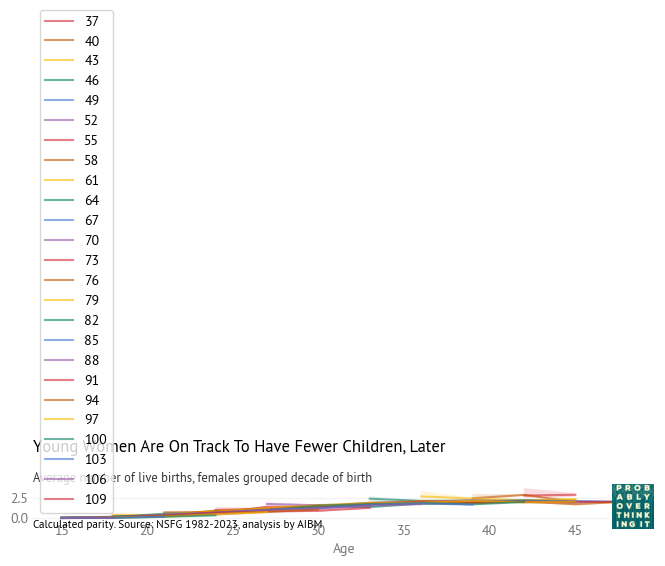

In [40]:
plot_table_with_errors(tables, cohorts, ages)
title = "Young Women Are On Track To Have Fewer Children, Later"
subtitle = "Average number of live births, females grouped decade of birth"
add_title(title, subtitle)

subtext = """
Calculated parity. Source: NSFG 1982-2023, analysis by AIBM"""
add_subtext(subtext)

decorate(xlabel="Age")
inset = add_logo()
savefig(1, inset)

### Percent who have born at least one child

`child_yes` is based on `parity`, which is a recode, so there's not a single question

In [41]:
tables = [make_table(resample_by_cycle(df), "child_yes") * 100 for i in range(101)]

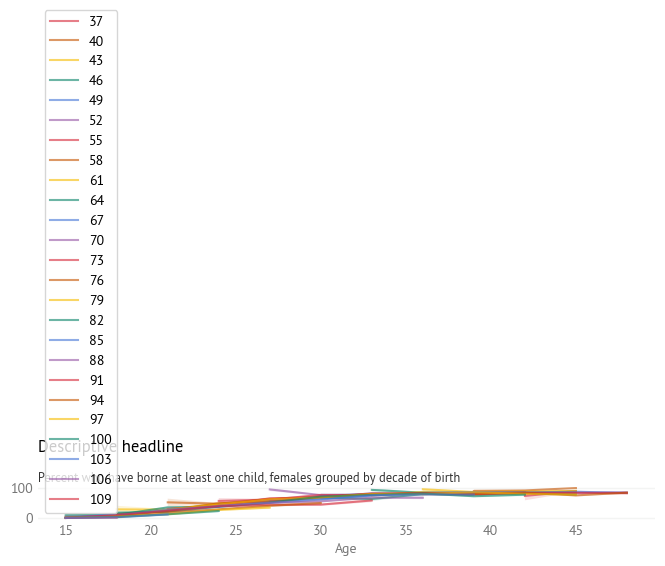

In [42]:
plot_table_with_errors(tables, cohorts, ages)
title = "Descriptive headline"
subtitle = (
    "Percent who have borne at least one child, females grouped by decade of birth"
)
add_title(title, subtitle)

# subtext: Question, NSFG 1982-2023 "

decorate(xlabel="Age")

### Expected additional births

`addexp` is a recoded "sentral number of additional births expected", based on a series of questions including "smallest" and "largest" number of babies

In [43]:
tables = [make_table(resample_by_cycle(df), "addexp") for i in range(101)]

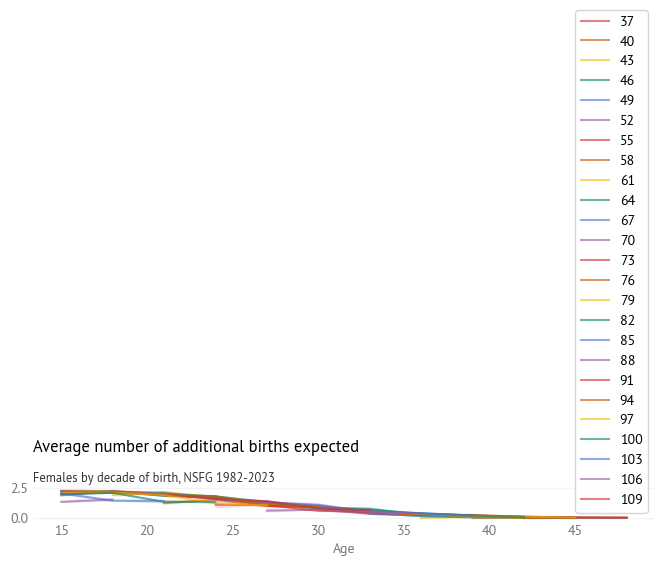

In [44]:
plot_table_with_errors(tables, cohorts, ages)
title = "Average number of additional births expected"
subtitle = "Females by decade of birth, NSFG 1982-2023 "
add_title(title, subtitle)

decorate(xlabel="Age")

### Sterilizing operations

`strl_yes` includes tubal ligation, hysterectory, and "other operation"

`strl_tubs` is only tubal ligation

In [45]:
df.groupby("cycle")["strl_yes"].mean()

cycle
3     0.004267
4     0.005444
5     0.000000
6     0.172053
7     0.151478
8     0.150509
9     0.141604
10    0.169968
11    0.165120
12    0.116720
Name: strl_yes, dtype: float64

In [46]:
recent = df.query("cycle >=6")

In [47]:
tables = [make_table(resample_by_cycle(recent), "strl_yes") * 100 for i in range(101)]

In [48]:
plot_table_with_errors(tables, cohorts, ages)
title = "Percent who have received surgical sterilization"
subtitle = "Females by decade of birth, NSFG 1982-2023 "
add_title(title, subtitle)

decorate(xlabel="Age")

KeyError: 37

## Male data

In [49]:
df2 = pd.read_parquet(interim("MaleMarriageData.parquet"))
df2.shape

(38769, 44)

In [50]:
df2.columns

Index(['caseid', 'cmbirth', 'timesmar', 'evrmarry', 'everoper', 'evrchil',
       'evrchiln', 'marrend4', 'cmdivw', 'rwant', 'fmarital', 'hieduc',
       'rmarital', 'mardat01', 'intent', 'addexp', 'finalwgt', 'cmintvw',
       'numbiokid', 'bdegree', 'anycoll', 'marend01', 'cmmarrhx', 'divorced',
       'separated', 'widowed', 'stillma', 'cycle', 'agemarry', 'ager',
       'missing', 'year', 'age_index', 'agemarry_index', 'birth_index',
       'fmarno', 'mar1diss', 'ftfmode', 'evbiokid', 'complete', 'complete_var',
       'ongoing_var', 'complete_missing', 'ongoing_missing'],
      dtype='object')

In [51]:
df2.groupby("cycle")["finalwgt"].describe()

,count,mean,std,min,25%,50%,75%,max
cycle,,,,,,,,
6,4928.0,12408.080664,13181.166931,494.853354,5100.934063,8129.115216,14649.566185,109064.168136
7,10403.0,5972.083308,7083.639572,38.700643,1775.486118,3484.639531,6980.739663,49735.071265
8,4815.0,12569.040291,13684.093019,1714.541000,4929.431343,8043.044705,14400.088306,85207.950000
9,4506.0,13572.387483,13109.264361,1859.105000,5668.692539,9279.889173,16067.881985,75399.410000
10,4540.0,15774.723348,17587.946794,1924.916000,5837.014310,9448.798531,18646.521019,106774.400000
11,5206.0,13872.816942,14750.387052,1340.862000,5050.599720,9048.322876,16133.803136,83332.130000
12,4371.0,17318.738586,14048.895074,1514.718391,7233.842329,12743.859416,22706.306280,95539.720755


In [52]:
pd.crosstab(df2["addexp"], df2["cycle"])

cycle,6,7,8,9,10,11,12
addexp,,,,,,,
0.0,1701,3515,1666,1590,1859,2134,2305
0.5,15,28,9,18,8,4,8
1.0,819,1832,806,812,750,893,562
1.5,30,47,15,28,20,30,22
2.0,1610,3334,1559,1410,1281,1488,1016
2.5,9,27,11,5,9,10,5
3.0,559,1138,525,457,403,460,295
3.5,1,4,5,4,2,4,1
4.0,115,311,151,126,134,111,100


In [53]:
trimmed = df2["addexp"] > 12
df2.loc[trimmed, "addexp"] = np.nan

In [54]:
pd.crosstab(df2["age_index"], df2["cycle"])

cycle,6,7,8,9,10,11,12
age_index,,,,,,,
15.0,194,456,168,179,166,186,112
16.0,235,464,236,207,177,186,152
17.0,192,473,236,233,174,223,129
18.0,271,513,216,198,198,230,162
19.0,224,454,226,177,171,207,144
20.0,191,351,141,164,119,117,76
21.0,182,360,161,119,153,131,83
22.0,190,343,183,155,103,139,91
23.0,170,346,171,149,135,133,111


In [55]:
from nsfg.utils import round_into_bins

df2["age_group"] = round_into_bins(df2["ager"], 3, low=14) + 1

In [56]:
# df2 gets age_group above but never birth_group, which make_table needs.
df2["birth_group"] = round_into_bins(df2["year"], 3, low=0) + 1

In [57]:
pd.crosstab(df2["age_group"], df2["cycle"])

cycle,6,7,8,9,10,11,12
age_group,,,,,,,
15.0,429,920,404,386,343,372,264
18.0,687,1440,678,608,543,660,435
21.0,563,1054,485,438,375,387,250
24.0,496,1061,504,452,410,419,315
27.0,444,1077,536,472,403,484,395
30.0,415,1006,448,474,430,470,397
33.0,449,895,467,430,387,524,473
36.0,442,923,362,405,358,432,449
39.0,442,883,380,318,337,405,430


In [58]:
pd.crosstab(df2["birth_index"], df2["cycle"])

cycle,6,7,8,9,10,11,12
birth_index,,,,,,,
50,322,0,0,0,0,0,0
60,1459,1857,292,60,349,156,0
70,1527,3133,1344,1211,1078,1219,685
80,1620,3710,1669,1536,1338,1575,1443
90,0,1703,1510,1680,1485,1505,1261
100,0,0,0,19,290,751,982


In [59]:
value_counts(df2["intent"])

,counts
values,
1.0,23218
2.0,15192
3.0,346
4.0,13


In [60]:
df2["intent_yes"] = np.where(df2["intent"].isna(), np.nan, df2["intent"] == 1)
df2["want_yes"] = np.where(df2["rwant"].isna(), np.nan, df2["rwant"] == 1)
df2["child_yes"] = np.where(df2["numbiokid"].isna(), np.nan, df2["numbiokid"] > 0)

In [61]:
# Have you ever had a vasectomy or any other operation that makes it
# impossible for you to father a child?
df2["strl_yes"] = np.where(df2["everoper"].isna(), np.nan, df2["everoper"] == 1)

### Do the responses depend on mode?

In [62]:
df2["ftfmode"].value_counts(normalize=True)

ftfmode
2.0    0.729581
1.0    0.270419
Name: proportion, dtype: float64

In [63]:
df2.groupby("ftfmode")["want_yes"].mean()

ftfmode
1.0    0.619705
2.0    0.542594
Name: want_yes, dtype: float64

In [64]:
df2.groupby(["birth_index", "ftfmode"])["want_yes"].mean()

birth_index  ftfmode
70           1.0        0.256098
             2.0        0.190099
80           1.0        0.477419
             2.0        0.405877
90           1.0        0.738411
             2.0        0.724891
100          1.0        0.838710
             2.0        0.794025
Name: want_yes, dtype: float64

In [65]:
df2.groupby("ftfmode")["intent_yes"].mean()

ftfmode
1.0    0.504230
2.0    0.433365
Name: intent_yes, dtype: float64

In [66]:
df2.groupby(["birth_index", "ftfmode"])["intent_yes"].mean()

birth_index  ftfmode
70           1.0        0.172414
             2.0        0.095890
80           1.0        0.330357
             2.0        0.281843
90           1.0        0.602985
             2.0        0.605832
100          1.0        0.750742
             2.0        0.713178
Name: intent_yes, dtype: float64

In [67]:
df2.groupby("ftfmode")["numbiokid"].mean()

ftfmode
1.0    0.734124
2.0    0.659134
Name: numbiokid, dtype: float64

In [68]:
df2.groupby(["birth_index", "ftfmode"])["numbiokid"].mean()

birth_index  ftfmode
70           1.0        1.511494
             2.0        1.298625
80           1.0        1.247761
             2.0        1.014467
90           1.0        0.498507
             2.0        0.333693
100          1.0        0.056380
             2.0        0.012403
Name: numbiokid, dtype: float64

In [69]:
from nsfg.utils import resample_by_cycle

sample = resample_by_cycle(df2)

In [70]:
table = make_table(sample, "want_yes") * 100
cohorts = table.columns
ages = table.index

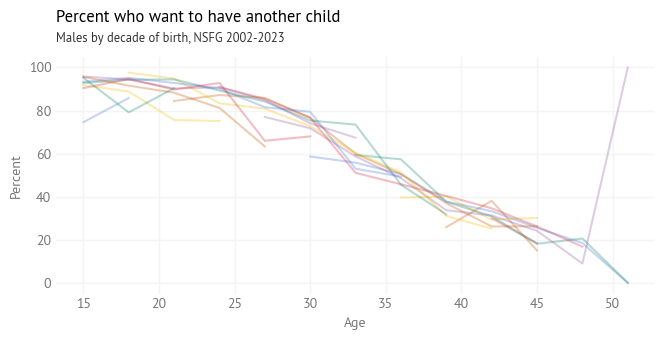

In [71]:
plot_table(table)
title = "Percent who want to have another child"
subtitle = "Males by decade of birth, NSFG 2002-2023 "
add_title(title, subtitle)

decorate(xlabel="Age", ylabel="Percent")

### Want

`rwant`

Looking to the future, do you, yourself, want to have another child at some time?

In [72]:
tables = [make_table(resample_by_cycle(df2), "want_yes") * 100 for i in range(101)]

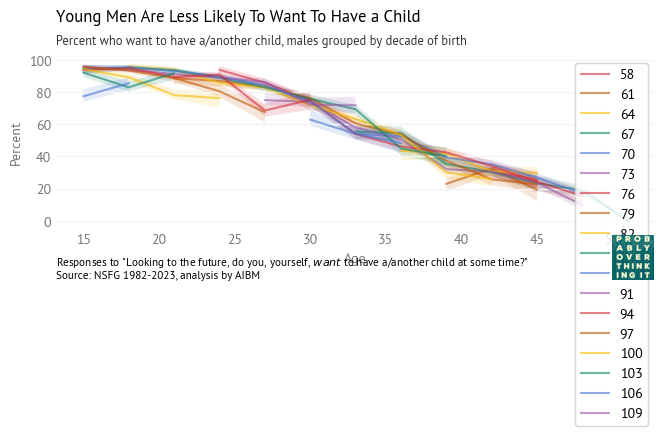

In [73]:
plot_table_with_errors(tables, cohorts, ages)
title = "Young Men Are Less Likely To Want To Have a Child"
subtitle = "Percent who want to have a/another child, males grouped by decade of birth"
add_title(title, subtitle)

subtext = """
Responses to "Looking to the future, do you, yourself, $want$ to have a/another child at some time?"
Source: NSFG 1982-2023, analysis by AIBM"""
add_subtext(subtext)

decorate(xlabel="Age", ylabel="Percent")
inset = add_logo()
savefig(5, inset)

In [74]:
summarize_age_group(tables, 24)

birth_group
58           NaN
61           NaN
64           NaN
67           NaN
70           NaN
73           NaN
76     93.655749
79     86.823947
82     85.609021
85     88.762384
88     89.712947
91     89.099632
94     90.995328
97     80.640204
100    76.020049
103          NaN
106          NaN
109          NaN
dtype: float64

"Among the young men (15 to 24) born in the 2000s, for example, 86% say they want children, compared to the 76% among their female peers. "

In [75]:
age_groups = [15, 18, 21, 24]
summarize_age_groups(df2, "want_yes", age_groups).dropna()

70     88.760421
80     91.840060
90     91.538769
100    85.724138
dtype: float64

### Intend

`intent`

Looking to the future, do you intend to have another child at some time?

In [76]:
tables = [make_table(resample_by_cycle(df2), "intent_yes") * 100 for i in range(101)]

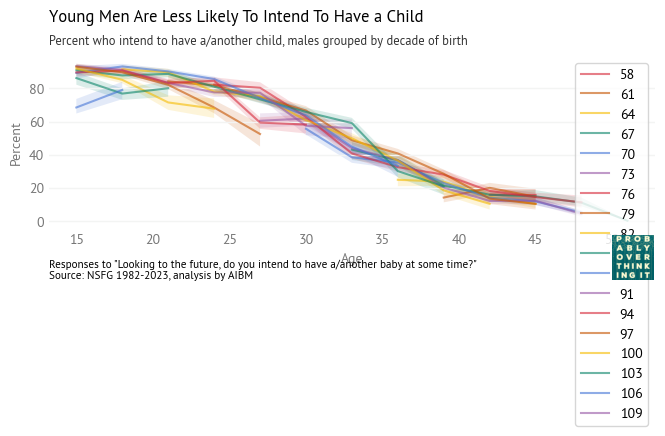

In [77]:
plot_table_with_errors(tables, cohorts, ages)
title = "Young Men Are Less Likely To Intend To Have a Child"
subtitle = (
    "Percent who intend to have a/another child, males grouped by decade of birth"
)
add_title(title, subtitle)

subtext = """
Responses to "Looking to the future, do you intend to have a/another baby at some time?"
Source: NSFG 1982-2023, analysis by AIBM"""
add_subtext(subtext)

decorate(xlabel="Age", ylabel="Percent")
inset = add_logo()
savefig(6, inset)

In [78]:
age_groups = [15, 18, 21, 24]
summarize_age_groups(df2, "intent_yes", age_groups).dropna()

70     82.212030
80     86.953973
90     85.851391
100    79.258446
dtype: float64

### Additional expected births

In [79]:
tables = [make_table(resample_by_cycle(df2), "addexp") for i in range(101)]

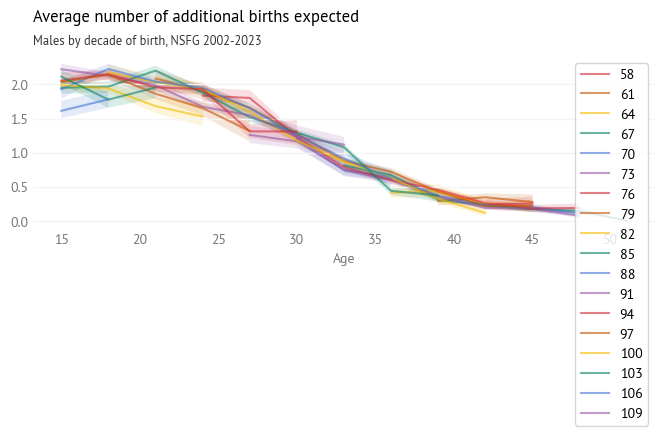

In [80]:
plot_table_with_errors(tables, cohorts, ages)
title = "Average number of additional births expected"
subtitle = "Males by decade of birth, NSFG 2002-2023 "
add_title(title, subtitle)

decorate(xlabel="Age")

### Number of children

`numbiokid`

"Altogether, how many biological children have you fathered?"

In [81]:
tables = [make_table(resample_by_cycle(df2), "numbiokid") for i in range(101)]

In [82]:
summary = summarize_age_group(tables, 33)
summary.round(1)

birth_group
58     NaN
61     NaN
64     NaN
67     1.3
70     1.3
73     1.5
76     1.5
79     1.3
82     1.2
85     0.9
88     1.0
91     0.6
94     NaN
97     NaN
100    NaN
103    NaN
106    NaN
109    NaN
dtype: float64

In [83]:
summary = summarize_age_group(tables, 24)
summary.round(1)

birth_group
58     NaN
61     NaN
64     NaN
67     NaN
70     NaN
73     NaN
76     0.5
79     0.4
82     0.5
85     0.4
88     0.3
91     0.3
94     0.2
97     0.2
100    0.1
103    NaN
106    NaN
109    NaN
dtype: float64

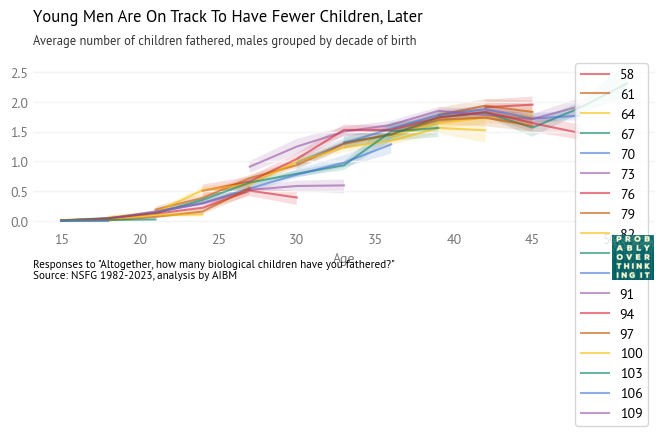

In [84]:
plot_table_with_errors(tables, cohorts, ages)
title = "Young Men Are On Track To Have Fewer Children, Later"
subtitle = "Average number of children fathered, males grouped by decade of birth"
add_title(title, subtitle)

subtext = """
Responses to "Altogether, how many biological children have you fathered?"
Source: NSFG 1982-2023, analysis by AIBM"""
add_subtext(subtext)

decorate(xlabel="Age")
inset = add_logo()
savefig(4, inset)

In [85]:
# it looks like there is one respondent over 50 who generates a spurious point
subset = df2.query("ager < 50")
tables = [make_table(resample_by_cycle(subset), "child_yes") * 100 for i in range(101)]

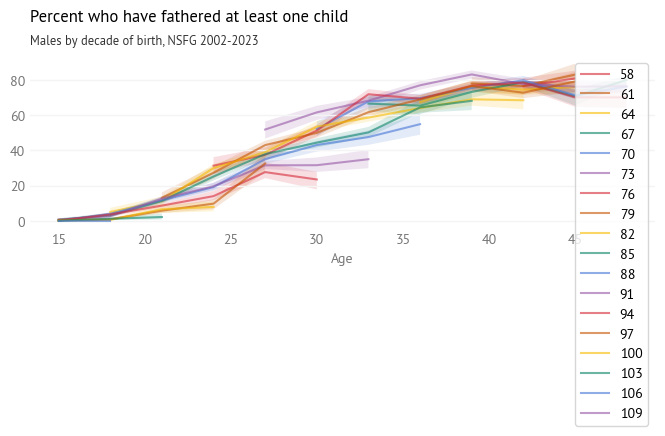

In [86]:
plot_table_with_errors(tables, cohorts, ages)
title = "Percent who have fathered at least one child"
subtitle = "Males by decade of birth, NSFG 2002-2023 "
add_title(title, subtitle)

decorate(xlabel="Age")

In [87]:
tables = [make_table(resample_by_cycle(df2), "strl_yes") * 100 for i in range(101)]

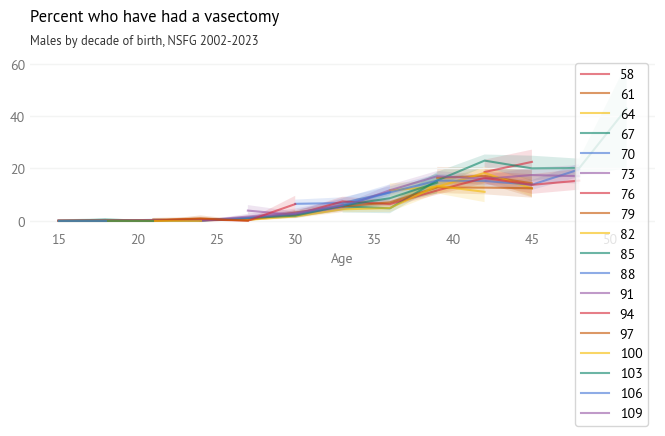

In [88]:
plot_table_with_errors(tables, cohorts, ages)
title = "Percent who have had a vasectomy"
subtitle = "Males by decade of birth, NSFG 2002-2023 "
add_title(title, subtitle)

decorate(xlabel="Age")

### Sterilizing operation

In [89]:
subset = df.query("cycle >= 10")
subset2 = df2.query("cycle >= 10")

In [90]:
def make_simple_table(df, var):
    """Group by age only, not cohort"""
    # subset = df.query("birth_index >= 60")
    table = df.groupby(["age_group"])[var].mean()
    return table

In [91]:
make_simple_table(subset, "strl_yes")

age_group
15.0    0.002039
18.0    0.001826
21.0    0.005848
24.0    0.027907
27.0    0.063113
30.0    0.092045
33.0    0.146163
36.0    0.214513
39.0    0.223638
42.0    0.305255
45.0    0.337369
48.0    0.443656
51.0    0.600000
Name: strl_yes, dtype: float64

In [92]:
tables = [
    make_simple_table(resample_by_cycle(subset), "strl_tubs") * 100 for i in range(101)
]

In [93]:
tables2 = [
    make_simple_table(resample_by_cycle(subset2), "strl_yes").drop(51) * 100
    for i in range(101)
]

In [94]:
def plot_simple_table_with_errors(tables, ages, color="C0", **options):
    frame = pd.DataFrame(columns=ages)
    for i, table in enumerate(tables):
        frame.loc[i] = table

    # using the 84% CI, so non-overlapping corresponds to
    # a difference that's significant at 5% level
    low, median, high = percentile_rows(frame, [8, 50, 92])
    plt.fill_between(ages, low, high, color=color, alpha=0.15)
    plt.plot(ages, median, color=color, **options)

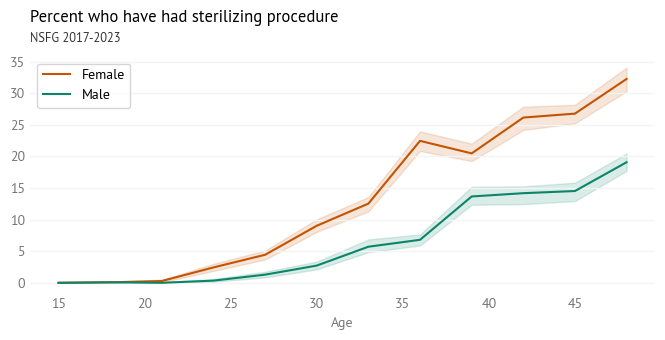

In [95]:
plot_simple_table_with_errors(tables, ages, color=aibm_orange, label="Female")
plot_simple_table_with_errors(tables2, ages, color=aibm_green, label="Male")

title = "Percent who have had sterilizing procedure"
subtitle = "NSFG 2017-2023 "
add_title(title, subtitle)

decorate(xlabel="Age")

## Differences

### Difference between want and intend for women

In [96]:
tables1 = [make_table(resample_by_cycle(df), "intent_yes") * 100 for i in range(101)]
tables2 = [make_table(resample_by_cycle(df), "want_yes") * 100 for i in range(101)]
diffs = [table2 - table1 for table1, table2 in zip(tables1, tables2)]

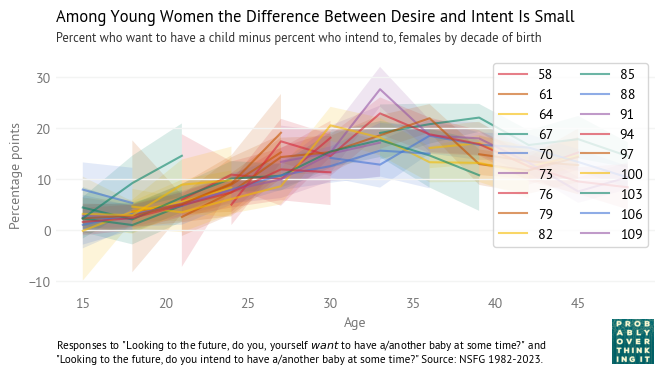

In [97]:
plot_table_with_errors(diffs, cohorts, ages)
title = "Among Young Women the Difference Between Desire and Intent Is Small"
subtitle = "Percent who want to have a child minus percent who intend to, females by decade of birth"
add_title(title, subtitle)

subtext = """
Responses to "Looking to the future, do you, yourself $want$ to have a/another baby at some time?" and
"Looking to the future, do you intend to have a/another baby at some time?" Source: NSFG 1982-2023."""
add_subtext(subtext)

plt.legend(ncol=2)
decorate(xlabel="Age", ylabel="Percentage points", legend=False)
inset = add_logo()
savefig(7, inset)

### Difference between want and intend for men

In [98]:
tables1 = [make_table(resample_by_cycle(df2), "intent_yes") * 100 for i in range(101)]
tables2 = [make_table(resample_by_cycle(df2), "want_yes") * 100 for i in range(101)]
diffs = [table2 - table1 for table1, table2 in zip(tables1, tables2)]

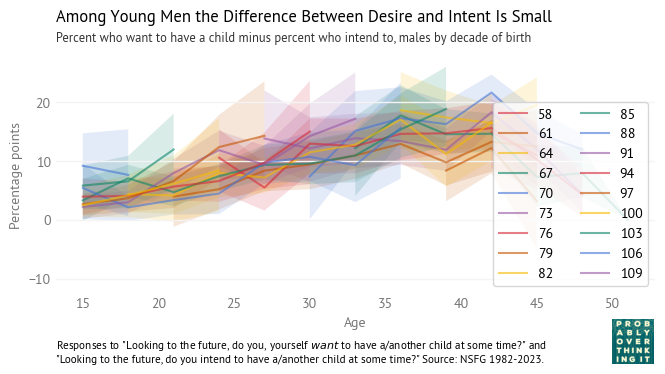

In [99]:
plot_table_with_errors(diffs, cohorts, ages)
title = "Among Young Men the Difference Between Desire and Intent Is Small"
subtitle = "Percent who want to have a child minus percent who intend to, males by decade of birth"
add_title(title, subtitle)

subtext = """
Responses to "Looking to the future, do you, yourself $want$ to have a/another child at some time?" and
"Looking to the future, do you intend to have a/another child at some time?" Source: NSFG 1982-2023."""
add_subtext(subtext)

plt.legend(ncol=2)
decorate(xlabel="Age", ylabel="Percentage points", legend=False)
inset = add_logo()
savefig(8, inset)

### Gender difference in desire for children

In [100]:
tables1 = [make_table(resample_by_cycle(df), "intent_yes") * 100 for i in range(101)]
tables2 = [make_table(resample_by_cycle(df2), "intent_yes") * 100 for i in range(101)]
diffs = [table2 - table1 for table1, table2 in zip(tables1, tables2)]

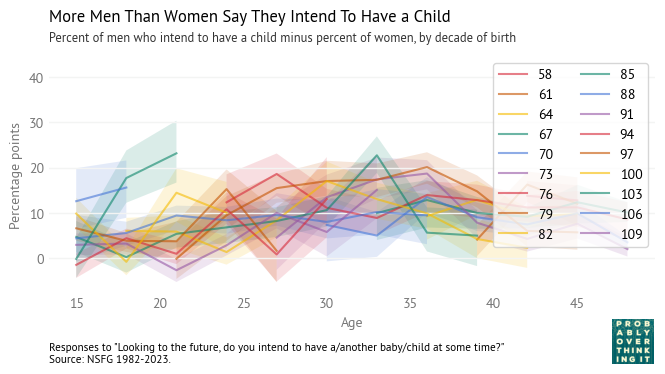

In [101]:
plot_table_with_errors(diffs, cohorts, ages)
title = "More Men Than Women Say They Intend To Have a Child"
subtitle = "Percent of men who intend to have a child minus percent of women, by decade of birth"
add_title(title, subtitle)

subtext = """
Responses to "Looking to the future, do you intend to have a/another baby/child at some time?" 
Source: NSFG 1982-2023."""
add_subtext(subtext)

plt.legend(ncol=2)
decorate(xlabel="Age", ylabel="Percentage points", legend=False)
inset = add_logo()
savefig(9, inset)

### Gender difference in desire for children

In [102]:
tables1 = [make_table(resample_by_cycle(df), "want_yes") * 100 for i in range(101)]
tables2 = [make_table(resample_by_cycle(df2), "want_yes") * 100 for i in range(101)]
diffs = [table2 - table1 for table1, table2 in zip(tables1, tables2)]

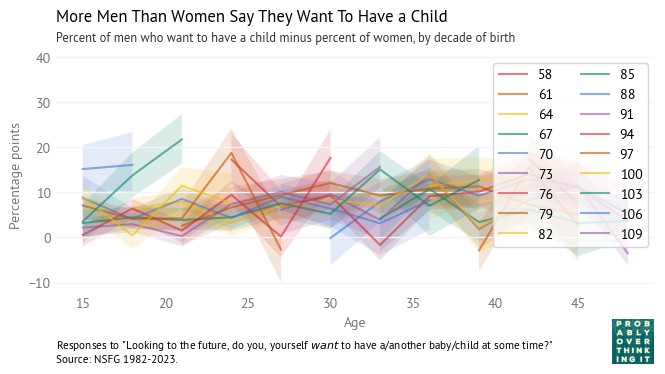

In [103]:
plot_table_with_errors(diffs, cohorts, ages)
title = "More Men Than Women Say They Want To Have a Child"
subtitle = (
    "Percent of men who want to have a child minus percent of women, by decade of birth"
)
add_title(title, subtitle)

subtext = """
Responses to "Looking to the future, do you, yourself $want$ to have a/another baby/child at some time?"
Source: NSFG 1982-2023."""
add_subtext(subtext)

plt.legend(ncol=2)
decorate(xlabel="Age", ylabel="Percentage points", legend=False)
inset = add_logo()
savefig(10, inset)

## Global fertility

In [104]:
import pandas as pd
import zipfile

# Define the zip file name
zip_filename = "period-total-fertility-rate.filtered.zip"

# Open the zip file and extract the CSV
with zipfile.ZipFile(zip_filename, "r") as z:
    # Get the list of files inside the zip
    file_list = z.namelist()

    # Assuming there's only one CSV file, extract its name
    csv_filename = [f for f in file_list if f.endswith(".csv")][0]

    # Read the CSV file into a DataFrame
    with z.open(csv_filename) as f:
        fertility_df = pd.read_csv(f)

fertility_df.columns

FileNotFoundError: [Errno 2] No such file or directory: 'period-total-fertility-rate.filtered.zip'

In [105]:
# Pivoting the DataFrame
df_pivot = fertility_df.pivot(
    index="Year", columns="Entity", values="Period total fertility rate - Total"
)[["United States", "Canada", "South Korea"]]
df_pivot.head()

NameError: name 'fertility_df' is not defined

In [106]:
colors = [aibm_blue, crimson, aibm_green]
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=colors)

df_pivot.plot(alpha=0.8)

title = "Fertility rates have declined in the U.S. and other developed countries"
subtitle = "Total fertility rate: births per woman"
add_title(title, subtitle)

subtext = """
Period fertility rates from Human Fertility Database (2024) via Our World in Data"""
add_subtext(subtext)

decorate(xlabel="Total fertility rate", ylabel="")
inset = add_logo()
savefig(11, inset)

NameError: name 'df_pivot' is not defined

In [107]:
df_pivot.loc[[2007, 2021], "United States"]

NameError: name 'df_pivot' is not defined

In [108]:
stop

NameError: name 'stop' is not defined

## Modeling attempts

In [109]:
subset = df.query("birth_index >= 60").copy()
subset["sqrt_parity"] = np.sqrt(subset["parity"])
subset["age2"] = (subset["ager"] - 30) ** 2
subset["age3"] = (subset["ager"] - 30) ** 3

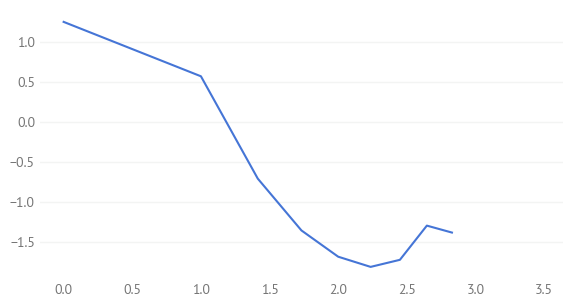

In [110]:
from scipy.special import logit

middle = subset.query("age_group >= 21 and age_group <= 33")
intent_series = middle.groupby("parity")["intent_yes"].mean()
x = np.sqrt(intent_series.index)
y = logit(intent_series)
plt.plot(x, y)

In [111]:
intention = subset.query("age_group <= 21").groupby("birth_index")["addexp"].mean()
intention

birth_index
60     2.009451
70     1.994594
80     1.984273
90     2.007411
100    1.667378
Name: addexp, dtype: float64

In [112]:
subset["intention"] = intention[subset["birth_index"]].values
subset["intention"].mean()

1.986249567597807

In [113]:
import statsmodels.formula.api as smf

formula = "intent_yes ~ ager + sqrt_parity + C(birth_index)"
results = smf.logit(formula=formula, data=subset).fit()

results.summary()

Optimization terminated successfully.
         Current function value: 0.472376
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             intent_yes   No. Observations:                61201
Model:                          Logit   Df Residuals:                    61194
Method:                           MLE   Df Model:                            6
Date:                Sun, 20 Sep 2026   Pseudo R-squ.:                  0.3178
Time:                        11:23:05   Log-Likelihood:                -28910.
converged:                       True   LL-Null:                       -42378.
Covariance Type:            nonrobust   LLR p-value:                     0.000
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 4.8241      0.054     89.718      0.000       4.719       4.929
C(birth_index)[T.70]      0.1113      0.030      3.766      0.000       0.053       0.169
C(birth_index)[T.80]      0.3074      0.029     10.708      0.000       0.251       0.364
C(birth_index)[T.90]     -0.1516      0.035     -4.278      0.000      -0.221      -0.082
C(birth_index)[T.100]    -1.4163      0.057    -24.641      0.000      -1.529      -1.304
ager                     -0.1402      0.002    -83.991      0.000      -0.143      -0.137
sqrt_parity              -1.0868      0.015    -70.228      0.000      -1.117      -1.057
=========================================================================================
"""

In [114]:
subset["parity"].mean(), subset["parity"].var()

(1.0872044574435058, 1.8067580034415684)

In [115]:
formula = "sqrt_parity ~ ager + age2 + age3 + C(birth_index)"
results = smf.ols(formula=formula, data=subset).fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            sqrt_parity   R-squared:                       0.313
Model:                            OLS   Adj. R-squared:                  0.313
Method:                 Least Squares   F-statistic:                     3984.
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:23:06   Log-Likelihood:                -57830.
No. Observations:               61201   AIC:                         1.157e+05
Df Residuals:                   61193   BIC:                         1.157e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.4264      0.021    -19.857      0.000      -0.468      -0.384
C(birth_index)[T.70]     -0.0042      0.007     -0.599      0.549      -0.018       0.009
C(birth_index)[T.80]     -0.0464      0.007     -6.406      0.000      -0.061      -0.032
C(birth_index)[T.90]     -0.1308      0.009    -15.256      0.000      -0.148      -0.114
C(birth_index)[T.100]    -0.0912      0.016     -5.868      0.000      -0.122      -0.061
ager                      0.0465      0.001     68.513      0.000       0.045       0.048
age2                     -0.0018   3.64e-05    -49.966      0.000      -0.002      -0.002
age3                  -2.527e-05    3.8e-06     -6.646      0.000   -3.27e-05   -1.78e-05
==============================================================================
Omnibus:                     1214.983   Durbin-Watson:                   1.850
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              687.329
Skew:                          -0.073   Prob(JB):                    5.60e-150
Kurtosis:                       2.502   Cond. No.                     1.34e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.34e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [116]:
pred_df = pd.DataFrame(dtype=float)
pred_df["ager"] = np.arange(15, 51, 3)
pred_df["age2"] = (pred_df["ager"] - 30) ** 2
pred_df["age3"] = (pred_df["ager"] - 30) ** 3
pred_df["birth_index"] = 100

pred = results.predict(pred_df) ** 2
pred = pd.Series(pred.values, pred_df["ager"])

In [117]:
table = make_table(subset, "parity")
table["2000s"].plot()
pred.plot()

KeyError: '2000s'